<h1 align="center">Spam Detection System</h1>

## Introduction
Spam messages are a common problem in digital communication, especially in emails and SMS. These unwanted messages not only waste time but can also contain harmful links or scams. Because of this, it is important to automatically identify and filter spam messages.

In this project, I built a spam detection system using different machine learning models. The goal was to classify messages as either spam or not spam based on their content. I experimented with multiple models and compared their performance to find the most effective approach.



## Problem Statement
The objective of this project is to develop a machine learning model that can accurately classify messages as spam or ham (not spam).

The main challenges in this project were working with text data and converting it into a format that machine learning models can understand. Another issue was the imbalance in the dataset, since normal messages are much more common than spam. It was also important to avoid false positives, where genuine messages get marked as spam. At the same time, the model should still be able to catch most of the spam messages.

The goal of this project is to build a model that can classify messages reliably, reducing mistakes while still maintaining strong overall performance.

In [135]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,ConfusionMatrixDisplay



In [136]:
df=pd.read_csv('spam.csv', encoding='latin-1')

In [137]:
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


# Data Cleaning and Preprocessing

In [138]:
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)

In [139]:
df.rename(columns={'v1':'target', 'v2':'text'}, inplace=True)

### The dataset originally had column names `v1` and `v2`. I renamed them to make them more meaningful and easier to understand.
### Here, the `text` column contains the actual message content, while the `target` column stores the labels, which indicate whether a message is spam or ham.

In [140]:
df['target'].value_counts()

target
ham     4825
spam     760
Name: count, dtype: int64

### There is a Imbalance in data 
* Rows with Spam Label-760 
* Rows with Ham Label - 4825

### Count Plot

Text(0, 0.5, 'Number of Data points')

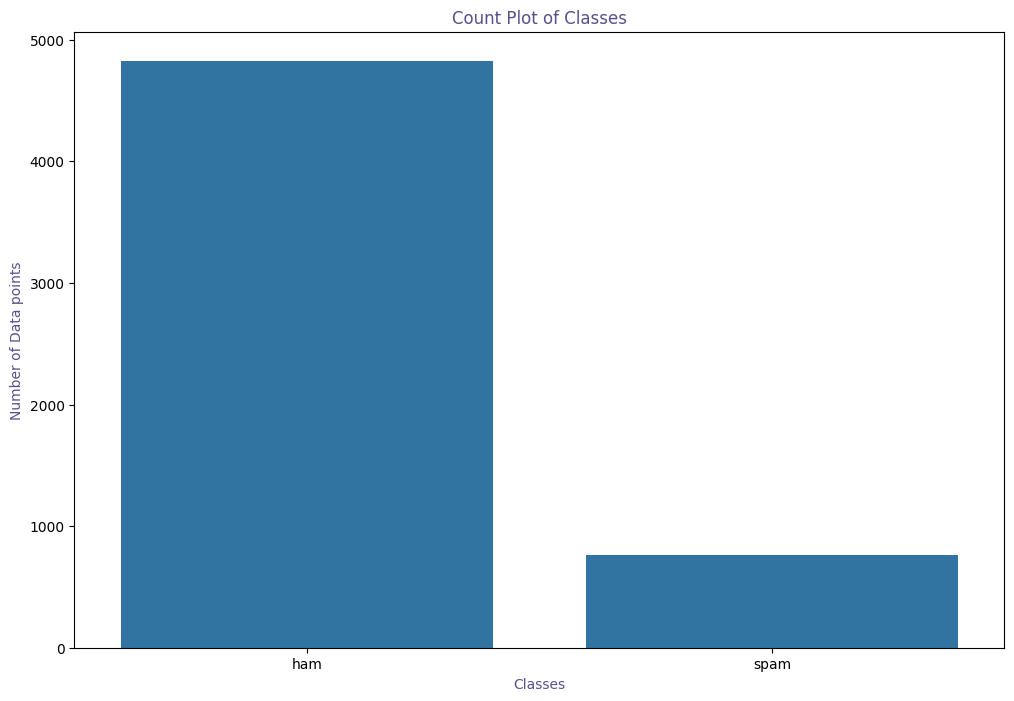

In [141]:
plt.figure(figsize=(12,8))
fg = sns.countplot(x= df["target"])
fg.set_title("Count Plot of Classes", color="#58508d")
fg.set_xlabel("Classes", color="#58508d")
fg.set_ylabel("Number of Data points", color="#58508d")

In [142]:
df["char_count"] = df["text"].apply(len)

In [143]:
df["word_count"] = df["text"].apply(lambda x: len(x.split()))

In [144]:
df["sentence_count"] = df["text"].apply(
    lambda x: len(re.split(r'[.!?]+', x)) - 1
)

In [145]:
df.head()

,target,text,char_count,word_count,sentence_count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20,3
1,ham,Ok lar... Joking wif u oni...,29,6,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,1
3,ham,U dun say so early hor... U c already then say...,49,11,2
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13,0


## PairPlot

<Figure size 1200x800 with 0 Axes>

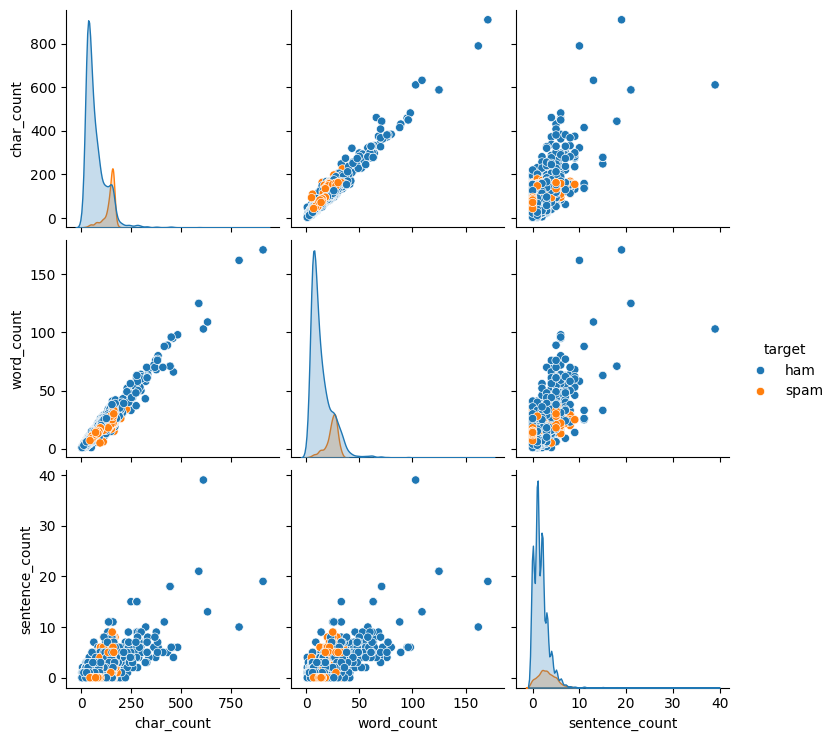

In [146]:
plt.figure(figsize=(12,8))
fg = sns.pairplot(data=df, hue="target")
plt.show(fg)

### From this we can see how the data is disturbuted.
### we have most of the disturbution around charcount 320,so we remove the others datas which have a charcount>320

## Removing Outlier

In [147]:
df=df[df["char_count"]<320]

<Figure size 1200x800 with 0 Axes>

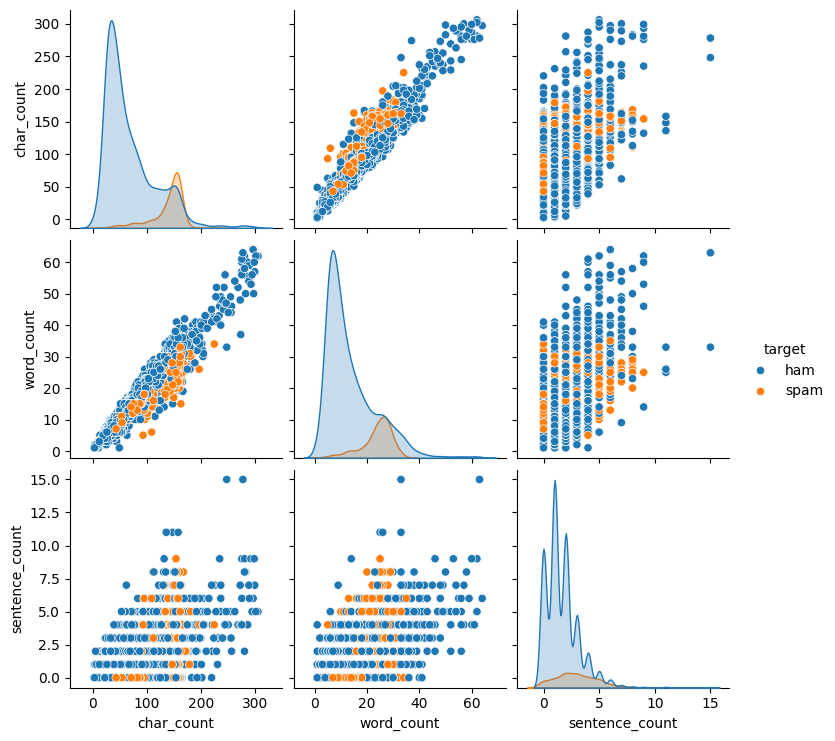

In [148]:
plt.figure(figsize=(12,8))
fg = sns.pairplot(data=df, hue="target")
plt.show(fg)

## TEXT PREPARATION

In [149]:
df["non_alpha_count"] = df["text"].apply(
    lambda x: len(re.findall(r"[^a-zA-Z]", x))
)

In [150]:
df["clean_text"] = df["text"].apply(
    lambda x: re.sub(r"[^a-zA-Z]", " ", x)
)

In [151]:
df["splited_words"] = df["clean_text"].apply(lambda x: x.split())

In [152]:

stop_words = set(stopwords.words("english"))

In [153]:
df["has_link"] = df["text"].str.contains("http").astype(int)
df["has_money"] = df["text"].str.contains("₹|$|€").astype(int)
df["has_urgent"] = df["text"].str.contains("urgent|now|quick|expire|ends|today|click here").astype(int)

In [154]:
df["has_link"].value_counts()

has_link
0    5531
1      21
Name: count, dtype: int64

In [155]:
df["has_money"].value_counts()

has_money
1    5552
Name: count, dtype: int64

In [156]:
df["has_urgent"].value_counts()

has_urgent
0    4713
1     839
Name: count, dtype: int64

In [157]:
df["rare_words"] = df["splited_words"].apply(
    lambda x: [word for word in x if word.lower() not in stop_words]
)

In [158]:
df.head()

,target,text,char_count,word_count,sentence_count,non_alpha_count,clean_text,splited_words,has_link,has_money,has_urgent,rare_words
0,ham,"Go until jurong point, crazy.. Available only ...",111,20,3,28,Go until jurong point crazy Available only ...,"[Go, until, jurong, point, crazy, Available, o...",0,1,0,"[Go, jurong, point, crazy, Available, bugis, n..."
1,ham,Ok lar... Joking wif u oni...,29,6,2,11,Ok lar Joking wif u oni,"[Ok, lar, Joking, wif, u, oni]",0,1,0,"[Ok, lar, Joking, wif, u, oni]"
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,1,58,Free entry in a wkly comp to win FA Cup fina...,"[Free, entry, in, a, wkly, comp, to, win, FA, ...",0,1,0,"[Free, entry, wkly, comp, win, FA, Cup, final,..."
3,ham,U dun say so early hor... U c already then say...,49,11,2,16,U dun say so early hor U c already then say,"[U, dun, say, so, early, hor, U, c, already, t...",0,1,0,"[U, dun, say, early, hor, U, c, already, say]"
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13,0,14,Nah I don t think he goes to usf he lives aro...,"[Nah, I, don, t, think, he, goes, to, usf, he,...",0,1,0,"[Nah, think, goes, usf, lives, around, though]"



## Lemmatized Words

Lemmatized words are the base or root form of words. In this process, words are converted into their original dictionary form.


In [159]:

lemmatizer = WordNetLemmatizer()

df["lemma_words"] = df["rare_words"].apply(
    lambda words: [lemmatizer.lemmatize(word, pos="v") for word in words])

In [160]:
df["lemma_text"] = df["lemma_words"].apply(lambda x: " ".join(x))

In [161]:
df.head(5)

,target,text,char_count,word_count,sentence_count,non_alpha_count,clean_text,splited_words,has_link,has_money,has_urgent,rare_words,lemma_words,lemma_text
0,ham,"Go until jurong point, crazy.. Available only ...",111,20,3,28,Go until jurong point crazy Available only ...,"[Go, until, jurong, point, crazy, Available, o...",0,1,0,"[Go, jurong, point, crazy, Available, bugis, n...","[Go, jurong, point, crazy, Available, bugis, n...",Go jurong point crazy Available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,29,6,2,11,Ok lar Joking wif u oni,"[Ok, lar, Joking, wif, u, oni]",0,1,0,"[Ok, lar, Joking, wif, u, oni]","[Ok, lar, Joking, wif, u, oni]",Ok lar Joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,1,58,Free entry in a wkly comp to win FA Cup fina...,"[Free, entry, in, a, wkly, comp, to, win, FA, ...",0,1,0,"[Free, entry, wkly, comp, win, FA, Cup, final,...","[Free, entry, wkly, comp, win, FA, Cup, final,...",Free entry wkly comp win FA Cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,49,11,2,16,U dun say so early hor U c already then say,"[U, dun, say, so, early, hor, U, c, already, t...",0,1,0,"[U, dun, say, early, hor, U, c, already, say]","[U, dun, say, early, hor, U, c, already, say]",U dun say early hor U c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13,0,14,Nah I don t think he goes to usf he lives aro...,"[Nah, I, don, t, think, he, goes, to, usf, he,...",0,1,0,"[Nah, think, goes, usf, lives, around, though]","[Nah, think, go, usf, live, around, though]",Nah think go usf live around though


In [162]:
df = df.reset_index(drop=True)

In [163]:
df.replace({'target': {'ham': 0, 'spam': 1}}, inplace=True)


C:\Users\Vijay\AppData\Local\Temp\ipykernel_7460\745904212.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'target': {'ham': 0, 'spam': 1}}, inplace=True)


## TF-IDF Vectorization

To convert text data into numerical features, I used the TF-IDF vectorizer with specific parameters.

In [164]:

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),   
    max_features=5000
)



## Feature Extraction

To prepare the data for model training, I converted the text into numerical form using TF-IDF (Term Frequency–Inverse Document Frequency).


In [165]:

X = tfidf.fit_transform(df["lemma_text"])
Y= df[["target"]]


## Spliting Dataset

In [166]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.1, random_state=42)

# Model Training:

## Naive bayes


In [167]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
pred_nb = nb.predict(X_test)

c:\Users\Vijay\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## Logistic Regression

In [168]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

c:\Users\Vijay\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## SVM

In [169]:
svm = SVC()
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)

c:\Users\Vijay\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## Decision Tree

In [170]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

## Random Forest

In [171]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

c:\Users\Vijay\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


# Accuracy Score


In [172]:
print("Accuracy of Naive Bayes:", accuracy_score(y_test, pred_nb))
print("Accuracy of Logistic Regression:", accuracy_score(y_test, pred_lr))
print("Accuracy of SVM:", accuracy_score(y_test, pred_svm))
print("Accuracy of Decision Tree:", accuracy_score(y_test, pred_dt))
print("Accuracy of Random Forest:", accuracy_score(y_test, pred_rf))

Accuracy of Naive Bayes: 0.9838129496402878
Accuracy of Logistic Regression: 0.9694244604316546
Accuracy of SVM: 0.9820143884892086
Accuracy of Decision Tree: 0.9694244604316546
Accuracy of Random Forest: 0.9784172661870504


# Precision Score

In [173]:
print("Precision Score For Naive Bayes:", precision_score(y_test, pred_nb))
print("Precision Score For Logistic Regression:", precision_score(y_test, pred_lr))
print("Precision Score For SVM:", precision_score(y_test, pred_svm))
print("Precision Score For Decision Tree:", precision_score(y_test, pred_dt))
print("Precision Score For Random Forest:", precision_score(y_test,pred_rf))



Precision Score For Naive Bayes: 0.9861111111111112
Precision Score For Logistic Regression: 0.984375
Precision Score For SVM: 0.9726027397260274
Precision Score For Decision Tree: 0.918918918918919
Precision Score For Random Forest: 0.9855072463768116


# Recall

In [174]:
print("Recall For Naive Bayes:", recall_score(y_test, pred_nb))
print("Recall For Logistic Regression:", recall_score(y_test, pred_lr))
print("Recall For SVM:", recall_score(y_test, pred_svm))
print("Recall For Decision Tree:", recall_score(y_test, pred_dt))
print("Recall For Random Forest:", recall_score(y_test,pred_rf))


Recall For Naive Bayes: 0.8987341772151899
Recall For Logistic Regression: 0.7974683544303798
Recall For SVM: 0.8987341772151899
Recall For Decision Tree: 0.8607594936708861
Recall For Random Forest: 0.8607594936708861


# F1 Score

In [175]:
print("F1 Score For Naive Bayes:", f1_score(y_test, pred_nb))
print("F1 Score For Logistic Regression:", f1_score(y_test, pred_lr))
print("F1 Score For SVM:", f1_score(y_test, pred_svm))
print("F1 Score For Decision Tree:", f1_score(y_test, pred_dt))
print("F1 Score For Random Forest:", f1_score(y_test,pred_rf))

F1 Score For Naive Bayes: 0.9403973509933775
F1 Score For Logistic Regression: 0.8811188811188811
F1 Score For SVM: 0.9342105263157895
F1 Score For Decision Tree: 0.8888888888888888
F1 Score For Random Forest: 0.918918918918919


# Confusion Matrix

### Naive Bayes

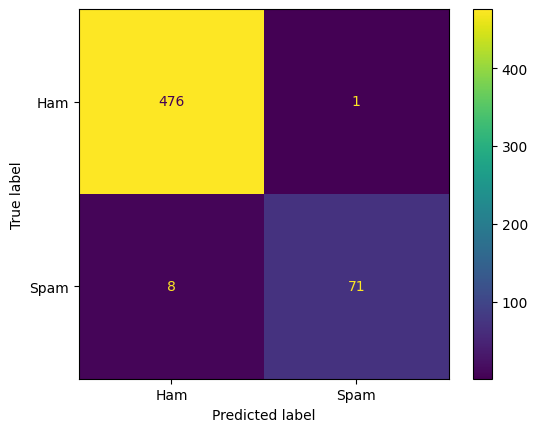

In [176]:
ConfusionMatrixDisplay.from_predictions(y_test, pred_nb, display_labels=["Ham", "Spam"])


### Logistic Regression

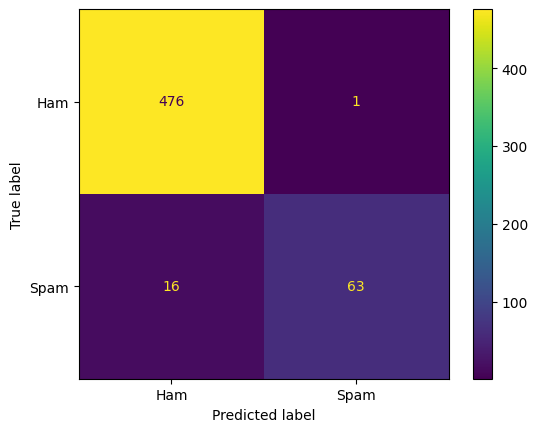

In [177]:
ConfusionMatrixDisplay.from_predictions(y_test, pred_lr, display_labels=["Ham", "Spam"])


### Random Forest

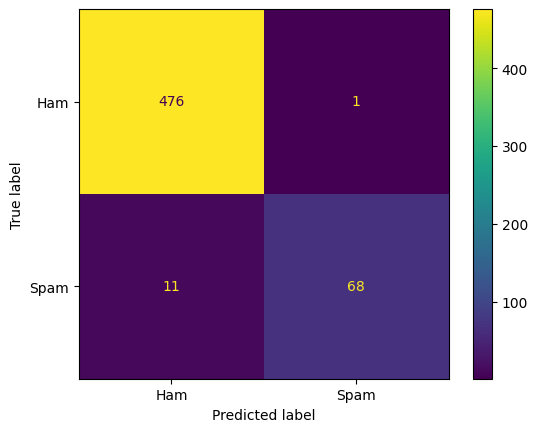

In [178]:
ConfusionMatrixDisplay.from_predictions(y_test, pred_rf, display_labels=["Ham", "Spam"])


### Decision Tree

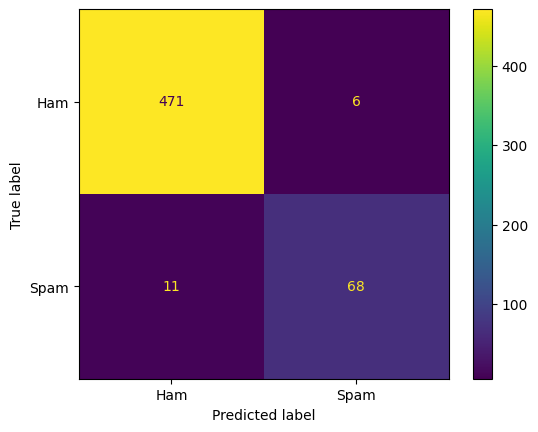

In [179]:
ConfusionMatrixDisplay.from_predictions(y_test, pred_dt, display_labels=["Ham", "Spam"])


### SVM

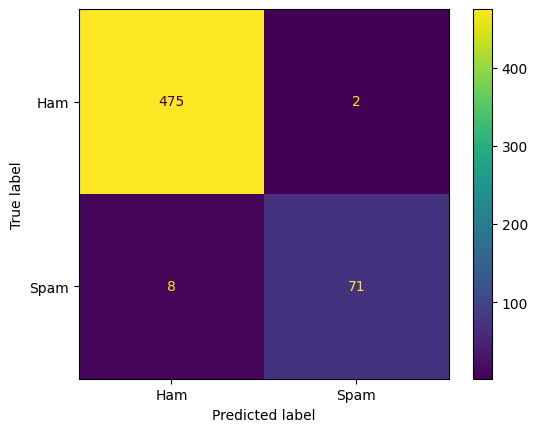

In [180]:
ConfusionMatrixDisplay.from_predictions(y_test, pred_svm, display_labels=["Ham", "Spam"])


#  Spam Detection Model Analysis

## Overview
In this project, I tested different machine learning models for spam detection, including Naive Bayes, Logistic Regression, SVM, Decision Tree, and Random Forest. I evaluated their performance using Accuracy, Precision, Recall,  F1 Score and Confusion Matrix.

## Best Model: Naive Bayes
Out of all the models, Naive Bayes performed the best overall.

F1 Score: 0.94  
Accuracy: 98.38%  
Precision: 98.61%  
Recall: ~89.87%  

It provides a good balance between precision and recall. I observed that it rarely classifies normal messages as spam, which means very low false positives. At the same time, it is able to detect most of the spam messages effectively.

## Other Models

### SVM and Random Forest
Both SVM and Random Forest showed very similar performance.

F1 Score: ~0.93  
Accuracy: ~98.2%  

They maintain a good balance between detecting spam and avoiding false alarms, making them strong alternatives to Naive Bayes.

## Logistic Regression
Precision: 98.43%  
Recall: 79.75%  

Logistic Regression gives highly reliable predictions when it labels a message as spam. However, it tends to miss more spam messages compared to the other models.

## Decision Tree
F1 Score: ~0.88  

Decision Tree performed lower than the other models. It was less consistent in identifying both spam and non-spam messages.

## Conclusion
Overall, Naive Bayes turned out to be the best model for this task. SVM and Random Forest also performed well and can be considered as good alternatives. Logistic Regression is very precise but misses more spam messages, while Decision Tree showed the least performance among all models.

This shows that Naive Bayes works especially well for text-based classification problems like spam detection.